<a href="https://colab.research.google.com/github/vinkoff/Learner/blob/master/Apps_GenAI_Module_2_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#From Gemni - Module 2: The Logic of the Guess – Mathematical
#Foundations

--- Part A: Vector Proximity ---
Similarity (Virus_Bio vs Doctor): 0.9968
Similarity (Virus_Bio vs Virus_Comp): 0.2219

--- Part B: The Risk Dial ---


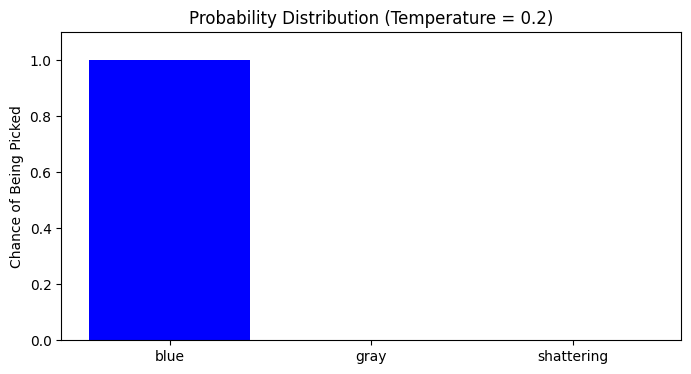

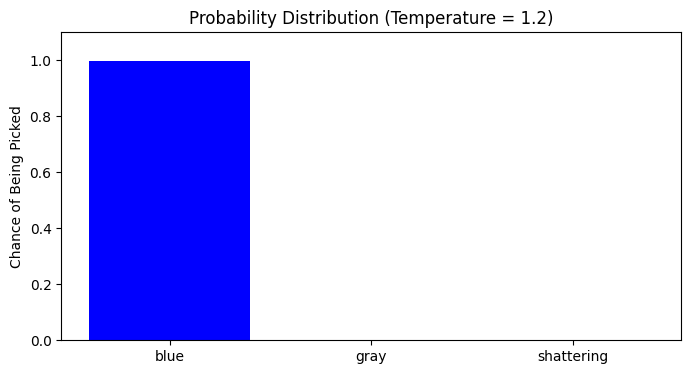

In [2]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

# --- Part A: Measuring Meaning (Embeddings) ---
# We use a mock-up of how words are mapped as coordinates (embeddings)
# In a real model, these would have hundreds of dimensions!
word_embeddings = {
    "Virus_Bio": torch.tensor([0.9, 0.1, 0.05]),   # High 'Medical' vibe
    "Virus_Comp": torch.tensor([0.1, 0.9, 0.05]),  # High 'Tech' vibe
    "Doctor": torch.tensor([0.85, 0.05, 0.1]),     # Near Bio Virus
    "Hacker": torch.tensor([0.15, 0.85, 0.2]),     # Near Comp Virus
}

def calculate_similarity(word1, word2):
    # Cosine similarity measures the "angle" between word-vectors
    sim = F.cosine_similarity(word_embeddings[word1].unsqueeze(0),
                              word_embeddings[word2].unsqueeze(0))
    return sim.item()

print(f"--- Part A: Vector Proximity ---")
print(f"Similarity (Virus_Bio vs Doctor): {calculate_similarity('Virus_Bio', 'Doctor'):.4f}")
print(f"Similarity (Virus_Bio vs Virus_Comp): {calculate_similarity('Virus_Bio', 'Virus_Comp'):.4f}")

# --- Part B: The Randomness Experiment (Temperature) ---
# Imagine these are the probabilities for: ["blue", "gray", "shattering"]
logits = torch.tensor([9.0, 1.0, 0.5])
words = ["blue", "gray", "shattering"]

def plot_temperature(temp):
    # Apply temperature to the logits before the Softmax "dice roll"
    scaled_logits = logits / temp
    probabilities = F.softmax(scaled_logits, dim=0).numpy()

    plt.figure(figsize=(8, 4))
    plt.bar(words, probabilities, color=['blue', 'gray', 'purple'])
    plt.title(f"Probability Distribution (Temperature = {temp})")
    plt.ylabel("Chance of Being Picked")
    plt.ylim(0, 1.1)
    plt.show()

print(f"\n--- Part B: The Risk Dial ---")
# Low Temperature (The Researcher)
plot_temperature(0.2)
# High Temperature (The Dreamer)
plot_temperature(1.2)

In [3]:
#The mental Fog Experiment Entropy and Loss
def calculate_metrics(prediction_probs, actual_index):
    # Entropy: Measures "Mental Fog" (higher = more confused)
    entropy = -torch.sum(prediction_probs * torch.log(prediction_probs + 1e-9)).item()

    # Loss: Measures "Surprise" (higher = confidently wrong)
    loss = -torch.log(prediction_probs[actual_index] + 1e-9).item()

    return entropy, loss

# Scenario 1: The AI is Confused (High Entropy)
# It thinks "blue", "gray", and "shattering" are all equally likely.
confused_probs = torch.tensor([0.33, 0.33, 0.34])

# Scenario 2: The AI is Confidently Correct (Low Entropy, Low Loss)
# It is 99% sure it's "blue", and it IS "blue".
correct_probs = torch.tensor([0.99, 0.005, 0.005])

# Scenario 3: The AI is Confidently WRONG (Low Entropy, High Loss)
# It is 99% sure it's "blue", but the answer was "shattering".
wrong_probs = torch.tensor([0.99, 0.005, 0.005])

# Results
ent_conf, loss_conf = calculate_metrics(confused_probs, 0)
ent_corr, loss_corr = calculate_metrics(correct_probs, 0)
ent_wrong, loss_wrong = calculate_metrics(wrong_probs, 2) # Target is "shattering" index 2

print(f"--- The 'Mental Fog' Lab ---")
print(f"Confused AI:  Entropy (Fog)={ent_conf:.2f}, Loss (Surprise)={loss_conf:.2f}")
print(f"Correct AI:   Entropy (Fog)={ent_corr:.2f}, Loss (Surprise)={loss_corr:.2f}")
print(f"Confidently Wrong: Entropy (Fog)={ent_wrong:.2f}, Loss (Surprise)={loss_wrong:.2f}")

--- The 'Mental Fog' Lab ---
Confused AI:  Entropy (Fog)=1.10, Loss (Surprise)=1.11
Correct AI:   Entropy (Fog)=0.06, Loss (Surprise)=0.01
Confidently Wrong: Entropy (Fog)=0.06, Loss (Surprise)=5.30


In [4]:
#The "Distance" Lab (Euclidean vs. Cosine)
# Word A: "Hospital" [Medical=0.9, Tech=0.1]
# Word B: "Doctor"   [Medical=0.8, Tech=0.05]
word_a = torch.tensor([0.9, 0.1])
word_b = torch.tensor([0.8, 0.05])

# 1. Euclidean Distance (The "Bird's Eye" Path)
# Measures the straight-line distance between two points.
euclidean = torch.dist(word_a, word_b)

# 2. Cosine Similarity (The "Angle" Path)
# Measures if the words are pointing in the same direction (same "vibe").
cosine = F.cosine_similarity(word_a.unsqueeze(0), word_b.unsqueeze(0))

print(f"--- The 'Distance' Lab ---")
print(f"Euclidean Distance: {euclidean.item():.4f} (Lower is closer)")
print(f"Cosine Similarity:  {cosine.item():.4f} (Higher is more similar)")

--- The 'Distance' Lab ---
Euclidean Distance: 0.1118 (Lower is closer)
Cosine Similarity:  0.9988 (Higher is more similar)


Not a problem! Let's translate that Insider Threat scenario into a functional Python script.

In this lab, we will simulate a user's behavior as a vector. We’ll measure how far that behavior drifts from "Normal" and see how the AI uses Cosine Similarity and Entropy to decide when to sound the alarm.

In [5]:
import torch
import torch.nn.functional as F

# --- Step 1: Define the "Normal" Baseline ---
# Coordinates: [System Access, Data Volume, Time of Day]
# Normal Admin: Low volume, standard hours, high system access.
normal_behavior = torch.tensor([0.9, 0.2, 0.8])

# --- Step 2: Define New Activities ---
activities = {
    "Routine Maintenance": torch.tensor([0.85, 0.25, 0.75]),
    "Potential Data Breach": torch.tensor([0.3, 0.95, 0.1]) # High volume, odd hours
}

def analyze_threat(activity_name, activity_vector):
    # 1. Measure Distance (Location)
    # Cosine similarity shows if the 'vibe' of the action matches normal work
    similarity = F.cosine_similarity(normal_behavior.unsqueeze(0),
                                     activity_vector.unsqueeze(0)).item()

    # 2. Measure Confusion (Entropy)
    # We turn the similarity into a probability: Is this 'Safe' or 'Threat'?
    # If similarity is 0.5, the model is 'confused' (High Entropy)
    prob_safe = similarity
    prob_threat = 1.0 - similarity
    probs = torch.tensor([prob_safe, prob_threat])
    entropy = -torch.sum(probs * torch.log(probs + 1e-9)).item()

    print(f"--- Analyzing: {activity_name} ---")
    print(f"Similarity to Normal: {similarity:.4f}")
    print(f"Model Entropy (Fog):  {entropy:.4f}")

    if similarity < 0.6:
        print("🚨 ALERT: Anomalous behavior detected! Neighborhood shift confirmed.")
    else:
        print("✅ Activity within safe parameters.")
    print("-" * 30)

# Run the simulation
analyze_threat("Routine Maintenance", activities["Routine Maintenance"])
analyze_threat("Potential Data Breach", activities["Potential Data Breach"])

--- Analyzing: Routine Maintenance ---
Similarity to Normal: 0.9986
Model Entropy (Fog):  0.0105
✅ Activity within safe parameters.
------------------------------
--- Analyzing: Potential Data Breach ---
Similarity to Normal: 0.4418
Model Entropy (Fog):  0.6864
🚨 ALERT: Anomalous behavior detected! Neighborhood shift confirmed.
------------------------------
